# Storm Events — Missing Values Assessment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_rows", 60)
pd.set_option("display.max_columns", 40)

In [3]:
df = pd.read_csv("./work/StormEvents.csv", low_memory=False)
print(f"Rows: {len(df):,}   Columns: {df.shape[1]}")
print(f"Time span: {df['YEAR'].min()} → {df['YEAR'].max()}")

Rows: 1,830,044   Columns: 51
Time span: 1950 → 2025


## 1. Columns with missing values

In [4]:
missing = (
    (df.isna().sum() / len(df) * 100)
    .rename("missing_%")
    .rename_axis("column")
    .sort_values(ascending=False)
    .reset_index()
)
missing

,column,missing_%
0,CATEGORY,99.972788
1,TOR_OTHER_CZ_FIPS,99.827764
2,TOR_OTHER_CZ_NAME,99.827764
3,TOR_OTHER_WFO,99.827436
4,TOR_OTHER_CZ_STATE,99.827436
5,TOR_F_SCALE,95.976545
6,FLOOD_CAUSE,94.385490
7,TOR_WIDTH,85.229699
8,TOR_LENGTH,85.229699
9,MAGNITUDE_TYPE,74.045487


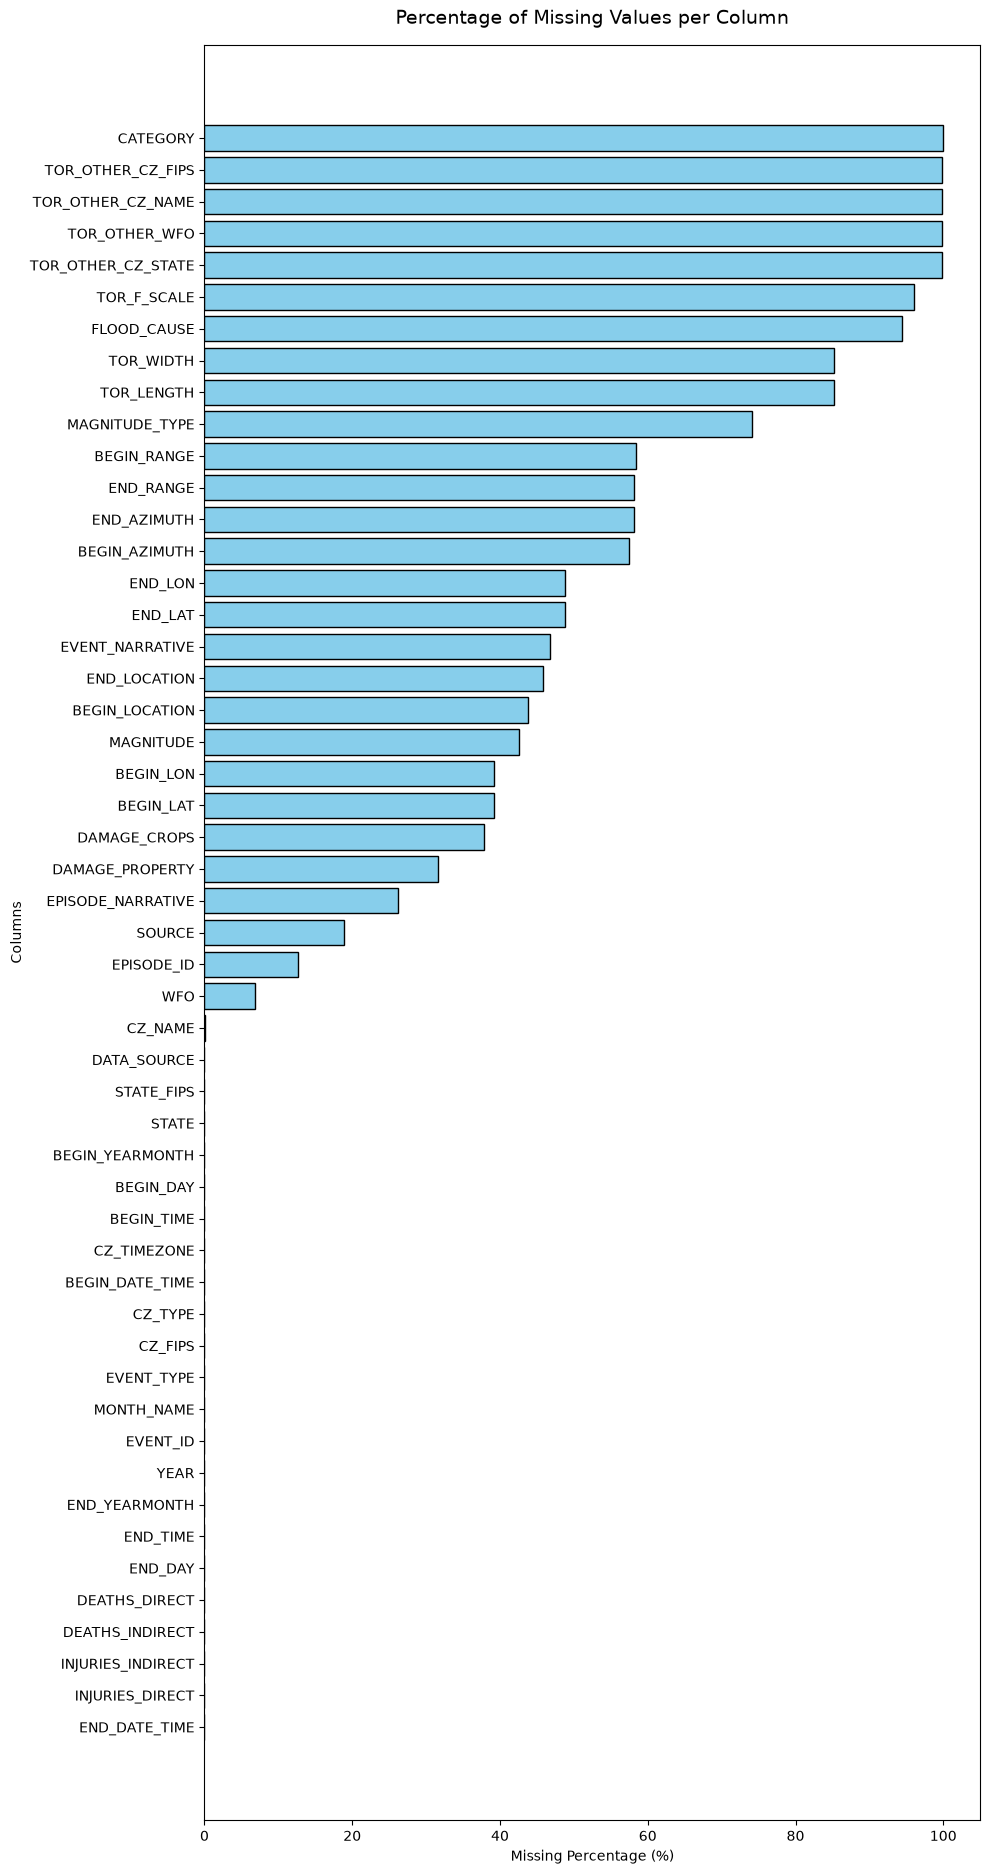

In [5]:
plt.figure(figsize=(10, 0.35 * len(missing) + 1))

# Use barh for horizontal bars
plt.barh(missing["column"], missing["missing_%"], color="skyblue", edgecolor="black")

# Invert the y-axis so the highest missing percentage is at the top
plt.gca().invert_yaxis()

plt.title("Percentage of Missing Values per Column", fontsize=14, pad=15)
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Columns")

plt.tight_layout()
plt.show()

## 2. Missing sit in time

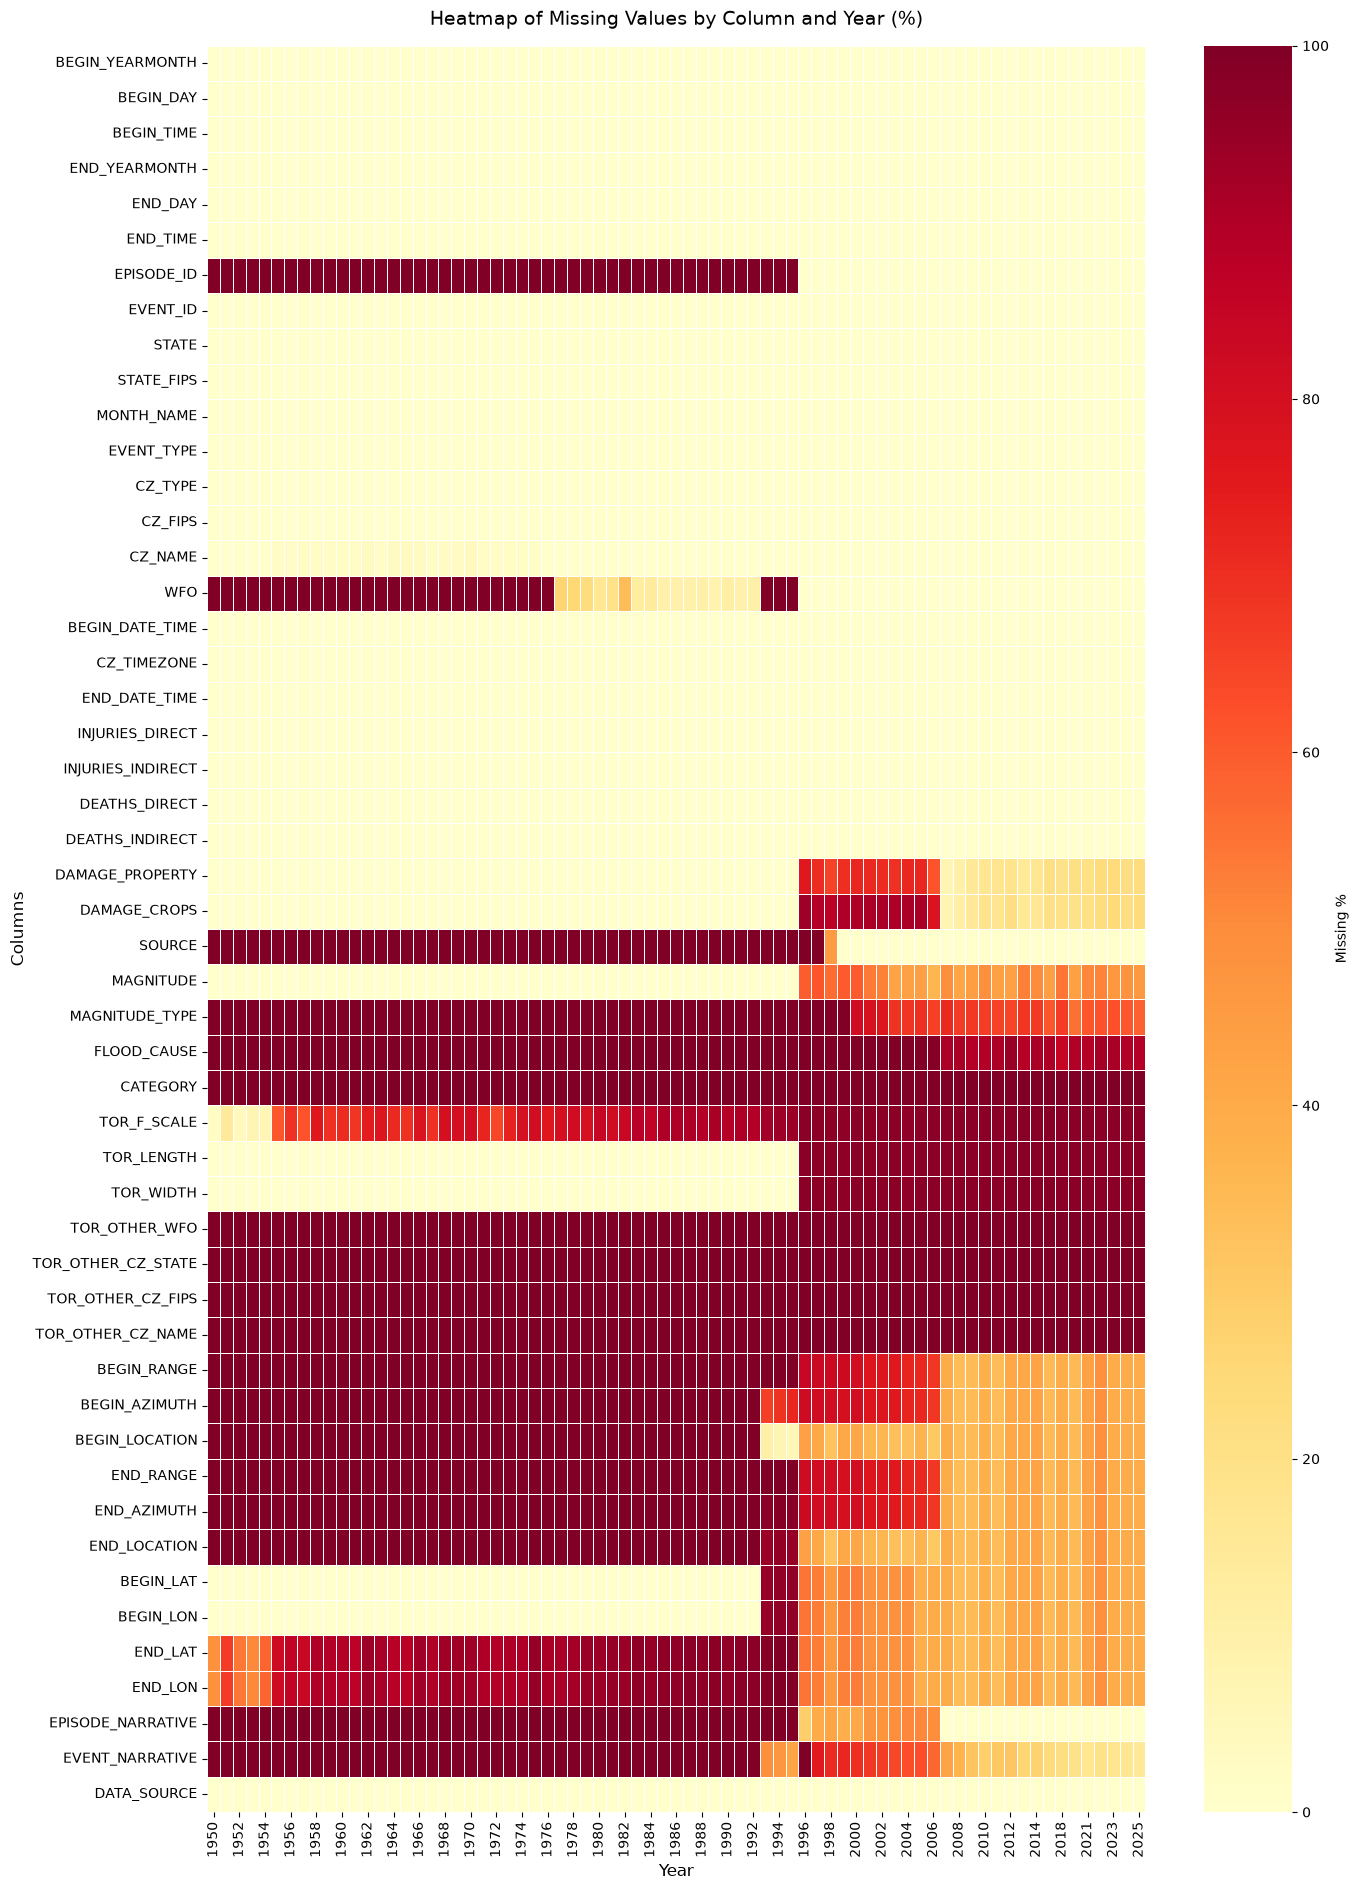

In [6]:
# 1. Missing percentage per column, grouped by 'YEAR'
feature_cols = [c for c in df.columns if c != "YEAR"]
missing_by_year = df.groupby("YEAR")[feature_cols].apply(lambda g: g.isna().mean() * 100)

# 2. Transpose so columns sit on the Y-axis and years on the X-axis
grid = missing_by_year.T

# 3. Plot the vertical heatmap
plt.figure(figsize=(14, 0.35 * len(grid) + 1.5))

sns.heatmap(
    grid,
    # annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={'label': 'Missing %', 'location': 'right'}
)

plt.title("Heatmap of Missing Values by Column and Year (%)", fontsize=14, pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Columns", fontsize=12)

plt.tight_layout()
plt.show()